## Energy calculation for a single trip (with current)
In this notebook, we set up a basic simulation where one vessel moves over a 1D network path. We add the ConsumesEnergy and VesselProperties mixins to the vessel object. Based on the vessel and network properties, now also an estimate of the energy that is required to pass the edge at the set speed can be made. This noteboook investigates  the effect of adding a current on the overall emission performance. 

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# OpenTNSim mixins and utils
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object
from opentnsim.core.visualizations import generate_vessel_gantt_chart
from opentnsim.energy import ConsumesEnergy
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
)
from opentnsim.graph.visualizations import plot_graph

# package(s) needed for inspecting the output
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


#### 0. Create environment
We create the environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. This case we create a single edge of 100 km exactly.

In [3]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other point 100 km East from Point 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 100000) # East from Point 0

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
}

In [4]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coord in coords.items():
    FG.add_node(name, geometry=Point(coord[0], coord[1]))

In [5]:
# create list of edges
edges = [("0", "1"), ("1", "0")] # bi-directional edge

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

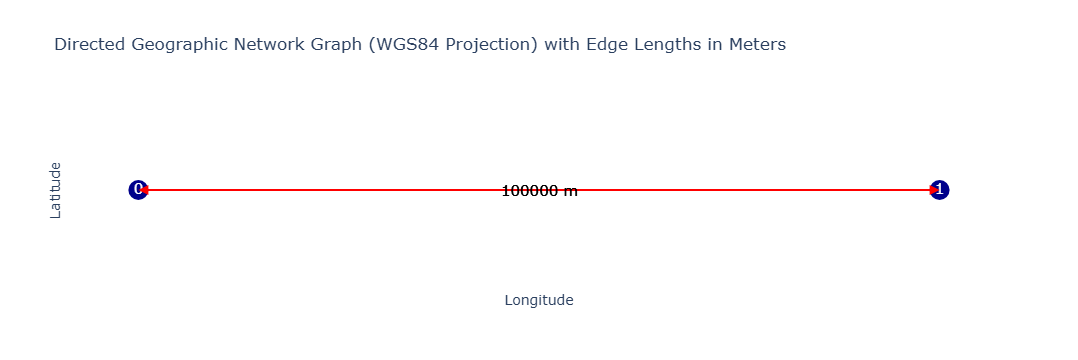

In [6]:
plot_graph(FG)

We now also add a current to the graph:

In [7]:
GeneralDepth = 10 # m
Current = 1 # m/s

# add graph to environment
FG.edges['0', '1'].update({'GeneralDepth': GeneralDepth, 'Current': -Current}) # from '0' to '1' you sail against the current
FG.edges['1', '0'].update({'GeneralDepth': GeneralDepth, 'Current':  Current}) # from '1' to '0' you sail with the current

In [8]:
# we add the graph to the environment
env.graph = FG

#### 2. Create vessel

In [9]:
# make your preferred Vessel class out of available mixins.
Vessel = create_object(
    "Vessel", 
    (
        ConsumesEnergy,
        Identifiable,                       # allows to give the object a name and a random ID,
        Movable,                            # allows the object to move, with a fixed speed, while logging this activity
        VesselProperties,
        ExtraMetadata,
    ), 
)

In [10]:
def mission(env, vessel):
    """Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [11]:
# create vessel from a dict 
route = nx.dijkstra_path(env.graph, "0", "1")
route.append('0')

data_vessel = {
    "env": env,
    "name": 'Vessel',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 135,                   # m
    "B": 11.45,                 # m
    "T": 2.75,                  # m
    "v": 3,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,           # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": False, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route[0]]['geometry'],
    "route": route,             # the route to sail
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
env.process(mission(env, vessel))

<Process(mission) object at 0x1fb1bfb5a90>

#### 3. Run simulation

In [12]:
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [13]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

display(df)

,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0.0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 13:53:20,100000.0,POINT (0.8983152841195217 0)
2,Sailing from node 1 to node 0 start,2024-01-01 13:53:20,100000.0,POINT (0.8983152841195217 0)
3,Sailing from node 1 to node 0 stop,2024-01-01 20:50:00,200000.0,POINT (0 0)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [14]:
df_eventtable = logbook2eventtable([vessel])
df_eventtable

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,8e6baa7a-e585-4e2e-a88e-d3686e78465d,Vessel,Sailing from node 0 to node 1,,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00,2024-01-01 13:53:20,100000.0,50000.0
1,8e6baa7a-e585-4e2e-a88e-d3686e78465d,Vessel,Sailing from node 1 to node 0,,POINT (0.8983152841195217 0),POINT (0 0),2024-01-01 13:53:20,2024-01-01 20:50:00,100000.0,25000.0


In [15]:
# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel])        

pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),speed over ground (m/s),speed through water (m/s),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,8e6baa7a-e585-4e2e-a88e-d3686e78465d,Vessel,Sailing from node 0 to node 1,,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00,2024-01-01 13:53:20,100000.0,50000.0,10.0,NaN,2.0,3.0,-1.0,1990.0,302.873956,302.873956,1750.0,4206.582719
1,8e6baa7a-e585-4e2e-a88e-d3686e78465d,Vessel,Sailing from node 1 to node 0,,POINT (0.8983152841195217 0),POINT (0 0),2024-01-01 13:53:20,2024-01-01 20:50:00,100000.0,25000.0,10.0,NaN,4.0,3.0,1.0,1990.0,302.873956,302.873956,1750.0,2103.291359


In [16]:
# add fuel attributes to the minimum event table with energy attributes
df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel])

pd.set_option('display.max_columns', None)
df_eventtable_energy_fuel

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),speed over ground (m/s),speed through water (m/s),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s)
0,8e6baa7a-e585-4e2e-a88e-d3686e78465d,Vessel,Sailing from node 0 to node 1,,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00,2024-01-01 13:53:20,100000.0,50000.0,10.0,NaN,2.0,3.0,-1.0,1990.0,302.873956,302.873956,1750.0,4206.582719,1.079218e+06,10.792184,21.584367,3.424066e+06,2120.144338,48336.909999,34.240655,0.021201,0.483369,68.48131,0.042403,0.966738
1,8e6baa7a-e585-4e2e-a88e-d3686e78465d,Vessel,Sailing from node 1 to node 0,,POINT (0.8983152841195217 0),POINT (0 0),2024-01-01 13:53:20,2024-01-01 20:50:00,100000.0,25000.0,10.0,NaN,4.0,3.0,1.0,1990.0,302.873956,302.873956,1750.0,2103.291359,5.396092e+05,5.396092,21.584367,1.712033e+06,1060.072169,24168.455000,17.120328,0.010601,0.241685,68.48131,0.042403,0.966738


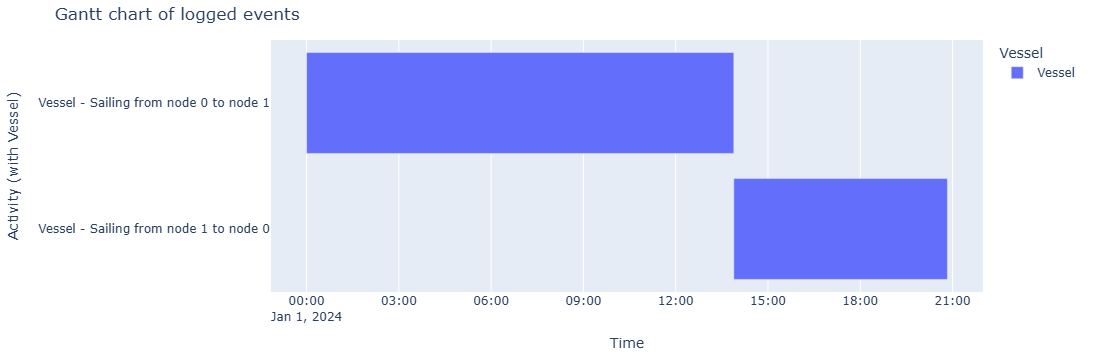

In [17]:
generate_vessel_gantt_chart(df_eventtable)

In [18]:
for index, row in df_eventtable_energy_fuel.iterrows(): 
    print('{} (current {:.0f} m/s): average P_tot {:.1f} kW, CO2 emission per m {:.1f} g/m, CO2 emissions per s {:.1f} g/s'.format(
        row['main activity name'], 
        row['current (m/s)'], 
        row['P_tot (kW)'], 
        row['CO2_emission_per_m (g/m)'], 
        row['CO2_emission_per_s (g/s)']))

Sailing from node 0 to node 1 (current -1 m/s): average P_tot 302.9 kW, CO2 emission per m 34.2 g/m, CO2 emissions per s 68.5 g/s
Sailing from node 1 to node 0 (current 1 m/s): average P_tot 302.9 kW, CO2 emission per m 17.1 g/m, CO2 emissions per s 68.5 g/s


The results in the event table, and the graph above, show the effect of current on the overall performance. The same distance obviously takes longer to complete when the current is against, then when it comes from behind. At a fixed speed the vessel emits the same emissions per second no matter if the current is from behind or against. But because it takes longer to pass an edge, the emissions per m are higher with an adverse current than a current from behind.